## 1. Install deps & mount Drive

In [2]:
!pip install -q openai beautifulsoup4 requests chromadb python-dotenv pandas "google-search-results" tiktoken sentence-transformers

import os
from pathlib import Path

# Colab: mount Drive and use persistent project root
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/research")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    PROJECT_ROOT = Path(".").resolve()

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "data").mkdir(exist_ok=True)
(PROJECT_ROOT / "cis").mkdir(exist_ok=True)
(PROJECT_ROOT / "cis" / "raw").mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT, "| Colab:", IN_COLAB)

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    from pip._internal.cli.spi

## 2. API keys & LLM backend

In [ ]:
try:
    from google.colab import userdata

    try:
        raw_key = userdata.get("OPENAI_API_KEY")
        if raw_key:
            # FIX: .strip() removes hidden newlines that cause "Illegal header" errors
            os.environ["OPENAI_API_KEY"] = raw_key.strip()
    except Exception:
        pass

    # Load SERPAPI_API_KEY (Optional)
    try:
        raw_serp = userdata.get("SERPAPI_API_KEY")
        if raw_serp:
            os.environ["SERPAPI_API_KEY"] = raw_serp.strip()
    except Exception:
        pass

except Exception as e:
    print(f"⚠️ Error accessing Colab Secrets: {e}")

# 2. Validate Critical Keys
if not os.environ.get("OPENAI_API_KEY"):
    print("❌ ERROR: OPENAI_API_KEY is missing! Please add it to the Secrets tab (Key icon on the left).")
else:
    print(f"✅ OPENAI_API_KEY loaded: ***{os.environ['OPENAI_API_KEY'][-4:]}")

print(f"✓ SERPAPI_API_KEY: {'Set (Google Bot Enabled)' if os.environ.get('SERPAPI_API_KEY') else 'Not Set (Google Bot Disabled)'}")

✅ OPENAI_API_KEY loaded: ***GKsA
✓ SERPAPI_API_KEY: Set (Google Bot Enabled)


## 3. Config

In [3]:
DATA_DIR = PROJECT_ROOT / "data"
CIS_RAW = PROJECT_ROOT / "cis" / "raw"
CIS_INDEX = PROJECT_ROOT / "cis" / "chroma_index"
QUESTIONS_PATH = DATA_DIR / "questions_62_ja.json"
RESULTS_PATH = DATA_DIR / "results_372.json"

GPT4, GPT35 = "gpt-4", "gpt-3.5-turbo-16k"
EMBED_MODEL = "text-embedding-ada-002"
RAG_INSTRUCTION = (
    "Answer ONLY using the provided context. "
    "Do NOT use prior knowledge. "
    "If the context does not contain sufficient information, "
    "respond exactly with: Insufficient information."
)

TOP_K_CIS, TOP_K_GOOGLE = 5, 10

# --- Reranking Settings ---
USE_RERANKING = True
TOP_N_INITIAL = 20  # Retrieve this many first
TOP_K_FINAL = 5     # Rerank and keep this many for the LLM
RERANK_MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-12-v2"

# --- Hard abstention threshold ---
ABSTENTION_THRESHOLD = 0.75

CIS_START = "https://ganjoho.jp/public/index.html"

# CIS: lite = cap pages (Colab-friendly). Full: set LITE_CRAWL=False.
LITE_CRAWL = True
MAX_PAGES_LITE = 80

# Set False to run only Conventional + Google (no CIS, no scraping).
RUN_CIS = True


## 4. Questions (upload `data/questions_62_ja.json` to Drive)

In [ ]:
import json

# Minimal fallback data (used only if file is missing)
MINIMAL_QUESTIONS = [
    {"id": 1, "text_ja": "私は札幌市北区に住んでいます。友人が胆管がんと診断されました。どの病院で治療を受けるのがおすすめでしょうか。", "cis_covered": True},
    {"id": 2, "text_ja": "赤酵母米のサプリメントはがんを悪化させる可能性がありますか。", "cis_covered": True},
    {"id": 3, "text_ja": "千葉市に重粒子線治療を行う病院があると聞き、主治医に相談したが紹介してくれなかった。なぜか。", "cis_covered": True},
]

if QUESTIONS_PATH.exists():
    try:
        # 1. Load the raw file
        text = QUESTIONS_PATH.read_text(encoding="utf-8")
        raw_data = json.loads(text)

        # 2. Handle nested structure (Fixes the "string indices must be integers" error)
        if isinstance(raw_data, dict):
            # Try to find the list inside the dictionary
            if "appendix_questions_ja" in raw_data:
                raw_list = raw_data["appendix_questions_ja"]
            else:
                # If the key name is unknown, grab the first value that is a list
                raw_list = next((v for v in raw_data.values() if isinstance(v, list)), [])
        else:
            raw_list = raw_data # It is already a list

        # 3. Standardize keys (Fixes missing 'text_ja' error)
        questions = []
        for item in raw_list:
            # Fix ID: "Q1" -> 1
            raw_id = item.get("id")
            if isinstance(raw_id, str) and raw_id.startswith("Q"):
                q_id = int(raw_id.replace("Q", ""))
            else:
                q_id = raw_id

            # Fix Text: "question" -> "text_ja"
            q_text = item.get("text_ja") or item.get("question")

            questions.append({
                "id": q_id,
                "text_ja": q_text,
                "cis_covered": True
            })

        print(f"✅ Loaded {len(questions)} questions from {QUESTIONS_PATH}")
        print(f"   Sample Q1: {questions[0]['text_ja'][:30]}...")

    except Exception as e:
        print(f"❌ Error parsing JSON: {e}")
        print("   Using minimal questions instead.")
        questions = MINIMAL_QUESTIONS
else:
    print("⚠️ File STILL not found at", QUESTIONS_PATH)
    print("   The code used the 3 dummy questions above.")
    questions = MINIMAL_QUESTIONS

✅ Loaded 62 questions from /content/drive/MyDrive/research/data/questions_62_ja.json
   Sample Q1: 札幌市北区に住んでいます 知人が胆管がんにかかったのですがど...


In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import CrossEncoder
# Load the Re-ranker
print("Loading Re-ranker...")
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-12-v2')
print("✔ Re-ranker loaded.")
# === HARD ABSTENTION CONFIG ===
ABSTENTION_THRESHOLD = 0.75


Loading Re-ranker...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✔ Re-ranker loaded.


## 5. CIS scraper. Run only when (re)building CIS data.

In [ ]:
import time
import hashlib
import requests
from bs4 import BeautifulSoup

CIS_BASE = "https://ganjoho.jp"
SEEN = set()

def _fname(url):
    h = hashlib.sha256(url.encode()).hexdigest()[:12]
    return CIS_RAW / f"{h}.txt"

def _extract(soup):
    for t in soup(["script", "style"]):
        t.decompose()
    return soup.get_text(separator="\n", strip=True)

def _links(soup):
    for a in soup.find_all("a", href=True):
        h = a["href"].split("#")[0].rstrip("/")
        if h.startswith("/") and not h.startswith("//"):
            yield CIS_BASE + h

def scrape_cis(start=CIS_START, lite=LITE_CRAWL, max_pages=MAX_PAGES_LITE):
    to_visit = [start]
    n = 0
    while to_visit and (not lite or n < max_pages):
        url = to_visit.pop(0)
        if url in SEEN or not url.startswith("https://ganjoho.jp"):
            continue
        SEEN.add(url)
        try:
            r = requests.get(url, timeout=15, headers={"User-Agent": "Mozilla/5.0 (research)"})
            r.raise_for_status()
            soup = BeautifulSoup(r.text, "html.parser")
            text = _extract(soup)
            if len(text) >= 100:
                _fname(url).write_text(text, encoding="utf-8")
                n += 1
            for L in _links(soup):
                if L not in SEEN:
                    to_visit.append(L)
        except Exception as e:
            print(url, e)
        time.sleep(0.4)
    print("CIS pages saved:", n, "under", CIS_RAW)

if RUN_CIS and not list(CIS_RAW.glob("*.txt")):
    scrape_cis(lite=LITE_CRAWL, max_pages=MAX_PAGES_LITE)
elif RUN_CIS:
    print("CIS raw exists. Delete cis/raw/* to re-crawl.")
else:
    print("RUN_CIS=False, skip scraper.")

CIS raw exists. Delete cis/raw/* to re-crawl.


## 6. CIS embed & Chroma index (only if RUN_CIS)

In [ ]:
import chromadb
from chromadb.utils import embedding_functions
import os
import time

# Define Batch Size (Safe limit to avoid 400 Errors)
BATCH_SIZE = 50

if RUN_CIS:
    # 1. Define the OpenAI Embedding Function
    openai_ef = embedding_functions.OpenAIEmbeddingFunction(
        api_key=os.environ.get("OPENAI_API_KEY"),
        model_name=EMBED_MODEL
    )

    # 2. Read and Chunk the text files
    chunks, ids = [], []
    if CIS_RAW.exists():
        for f in sorted(CIS_RAW.glob("*.txt")):
            t = f.read_text(encoding="utf-8")

            for p in t.split("\n\n"):
                p = p.strip()
                if len(p) < 80: continue

                for i in range(0, len(p), 500):
                    c = p[i : i + 500]
                    if len(c) < 80: continue
                    chunks.append(c)
                    ids.append(f"c{len(ids)}")

    # 3. Create/Update the Index (With Batching)
    if chunks:
        print(f"Preparing to embed {len(chunks)} chunks using OpenAI...")

        client = chromadb.PersistentClient(path=str(CIS_INDEX))

        coll = client.get_or_create_collection(
            name="cis",
            embedding_function=openai_ef,
            metadata={"hnsw:space": "cosine"}
        )

        # --- Loop through chunks in small batches ---
        total_batches = (len(chunks) + BATCH_SIZE - 1) // BATCH_SIZE

        for i in range(0, len(chunks), BATCH_SIZE):
            batch_ids = ids[i : i + BATCH_SIZE]
            batch_docs = chunks[i : i + BATCH_SIZE]

            # Send just this batch to OpenAI
            try:
                coll.upsert(ids=batch_ids, documents=batch_docs)
                print(f"  ✅ Batch {(i // BATCH_SIZE) + 1}/{total_batches} indexed ({len(batch_docs)} chunks)")
                time.sleep(0.5) # Polite delay
            except Exception as e:
                print(f"  ❌ Error on batch {(i // BATCH_SIZE) + 1}: {e}")

        print(f"🎉 Finished indexing {len(chunks)} chunks -> {CIS_INDEX}")
    else:
        print("⚠️ No chunks found. Did the Scraper (Step 5) download any pages?")
else:
    print("Skipping Indexing (RUN_CIS=False)")

Preparing to embed 910 chunks using OpenAI...
  ✅ Batch 1/19 indexed (50 chunks)
  ✅ Batch 2/19 indexed (50 chunks)
  ✅ Batch 3/19 indexed (50 chunks)
  ✅ Batch 4/19 indexed (50 chunks)
  ✅ Batch 5/19 indexed (50 chunks)
  ✅ Batch 6/19 indexed (50 chunks)
  ✅ Batch 7/19 indexed (50 chunks)
  ✅ Batch 8/19 indexed (50 chunks)
  ✅ Batch 9/19 indexed (50 chunks)
  ✅ Batch 10/19 indexed (50 chunks)
  ✅ Batch 11/19 indexed (50 chunks)
  ✅ Batch 12/19 indexed (50 chunks)
  ✅ Batch 13/19 indexed (50 chunks)
  ✅ Batch 14/19 indexed (50 chunks)
  ✅ Batch 15/19 indexed (50 chunks)
  ✅ Batch 16/19 indexed (50 chunks)
  ✅ Batch 17/19 indexed (50 chunks)
  ✅ Batch 18/19 indexed (50 chunks)
  ✅ Batch 19/19 indexed (10 chunks)
🎉 Finished indexing 910 chunks -> /content/drive/MyDrive/research/cis/chroma_index


## 7. LLM caller

In [ ]:
from openai import OpenAI
import os

def call_llm(user_content, model_label):
    """
    model_label: 'gpt4' or 'gpt35'
    """
    # 1. Initialize Client
    try:
        client = OpenAI()
    except Exception as e:
        return f"[ERROR: Could not init OpenAI client. {e}]"

    # 2. Select Model
    # These variables (GPT4, GPT35) were defined in Step 2
    if model_label == "gpt4":
        model_name = GPT4
    elif model_label == "gpt35":
        model_name = GPT35
    else:
        model_name = GPT35 # Default fallback

    # 3. Call API
    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": user_content}],
            temperature=0, # Deterministic (Critical for replication)
            max_tokens=1024
        )
        return (response.choices[0].message.content or "").strip()

    except Exception as e:
        print(f"❌ LLM Error ({model_name}): {e}")
        return f"[ERROR: {str(e)}]"

print("✅ LLM function defined. Ready to talk to GPT-4 and GPT-3.5.")

✅ LLM function defined. Ready to talk to GPT-4 and GPT-3.5.


## 8. Retrievers (CIS, Google, Conventional)

In [ ]:
import chromadb
from openai import OpenAI
from serpapi import GoogleSearch
import os

# =========================
# STRICT RAG CONTEXT FETCH
# =========================

def get_improved_cis_context(question_ja):
    try:
        client = chromadb.PersistentClient(path=str(CIS_INDEX))
        coll = client.get_collection("cis")

        # Embed the question
        openai_client = OpenAI()
        emb = openai_client.embeddings.create(
            input=[question_ja],
            model=EMBED_MODEL
        ).data[0].embedding

        # Retrieve candidates
        results = coll.query(
            query_embeddings=[emb],
            n_results=TOP_N_INITIAL,
            include=["documents"]
        )

        docs = results["documents"][0] if results.get("documents") else []
        if not docs:
            return None  # 🚨 HARD STOP

        # Re-rank
        pairs = [(question_ja, doc) for doc in docs]
        scores = reranker.predict(pairs)

        ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)

        # 🚨 HARD ABSTENTION GATE
        if ranked[0][1] < ABSTENTION_THRESHOLD:
            return None

        top_docs = [doc for doc, _ in ranked[:TOP_K_FINAL]]
        return "\n\n".join(top_docs)

    except Exception as e:
        print(f"[CIS ERROR] {e}")
        return None  # 🚨 NEVER pass error text to LLM


def get_improved_google_context(question_ja):
    try:
        if not os.environ.get("SERPAPI_API_KEY"):
            return None  # 🚨 HARD STOP

        params = {
            "q": question_ja,
            "api_key": os.environ["SERPAPI_API_KEY"],
            "num": TOP_N_INITIAL,
            "hl": "ja",
            "gl": "jp"
        }

        search = GoogleSearch(params)
        results = search.get_dict().get("organic_results", [])
        snippets = [
            f"{r.get('title','')}\n{r.get('snippet','')}"
            for r in results
        ]

        if not snippets:
            return None  # 🚨 HARD STOP

        pairs = [(question_ja, s) for s in snippets]
        scores = reranker.predict(pairs)
        ranked = sorted(zip(snippets, scores), key=lambda x: x[1], reverse=True)

        # 🚨 HARD ABSTENTION GATE
        if ranked[0][1] < ABSTENTION_THRESHOLD:
            return None

        top_docs = [doc for doc, _ in ranked[:TOP_K_FINAL]]
        return "\n\n".join(top_docs)

    except Exception as e:
        print(f"[GOOGLE ERROR] {e}")
        return None  # 🚨 NEVER pass error text to LLM


# Expose functions for next step
cis_context = get_improved_cis_context
google_context = get_improved_google_context


In [ ]:
import json

# 1. Reload the file you moved
with open(QUESTIONS_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# 2. Fix the structure (Unwrap the list from the dictionary)
if isinstance(raw_data, dict) and "appendix_questions_ja" in raw_data:
    raw_list = raw_data["appendix_questions_ja"]
else:
    raw_list = raw_data # It might already be a list

# 3. Fix the keys (The notebook needs "text_ja", not "question")
questions = []
for item in raw_list:
    # Fix ID: Convert "Q1" -> 1 (integer)
    raw_id = item.get("id")
    if isinstance(raw_id, str) and raw_id.startswith("Q"):
        q_id = int(raw_id.replace("Q", ""))
    else:
        q_id = raw_id

    # Fix Text: Map "question" -> "text_ja"
    q_text = item.get("text_ja") or item.get("question")

    questions.append({
        "id": q_id,
        "text_ja": q_text,
        "cis_covered": True # Default flag needed for the loop
    })

print(f"✅ SUCCESS: Fixed {len(questions)} questions.")
print(f"Sample format: {questions[0]}")
print("You can now run Step 9!")

✅ SUCCESS: Fixed 62 questions.
Sample format: {'id': 1, 'text_ja': '札幌市北区に住んでいます 知人が胆管がんにかかったのですがどの病院で治療を受けるのがよいですか', 'cis_covered': True}
You can now run Step 9!


In [ ]:
print("questions:", "questions" in globals())
print("cis_context:", "cis_context" in globals())
print("google_context:", "google_context" in globals())
print("reranker:", "reranker" in globals())
print("RESULTS_PATH:", RESULTS_PATH)


questions: True
cis_context: True
google_context: True
reranker: False
RESULTS_PATH: /content/drive/MyDrive/research/data/results_372.json


In [ ]:
# --- FORCE OVERWRITE OLD RESULT FILES ---

from pathlib import Path

files_to_overwrite = [
    RESULTS_PATH,                          # results_372.json
    DATA_DIR / "results_graded.csv"        # graded results
]

for f in files_to_overwrite:
    if f.exists():
        f.unlink()
        print(f"🗑️ Deleted old file: {f.name}")
    else:
        print(f"ℹ️ File not found (ok): {f.name}")

print("✅ Ready for a fresh run.")


ℹ️ File not found (ok): results_372.json
ℹ️ File not found (ok): results_graded.csv
✅ Ready for a fresh run.


## 9. Run all chatbots → `data/results_372.json` (or results_248 if RUN_CIS=False)

In [ ]:
import json
import pandas as pd
from openai import OpenAI
import time

# --- DEFINE THE JUDGE (GPT-4o Mini) ---
def automated_judge(question, context, answer):
    """
    Uses GPT-4o-mini to check if the answer is supported by the context.
    Returns 1 (Hallucination) or 0 (Faithful).
    """
    # 1. Automatic Pass for Refusals (Save money/time)
    safe_phrases = [
    "insufficient information",
    "information not available",
    "no relevant information",
    "i cannot answer",
    "context does not contain"
]

    if any(phrase.lower() in answer.lower() for phrase in safe_phrases):
        return 0

    # 2. Construct Prompt
    judge_prompt = f"""
    You are a strict medical fact-checker.

    CONTEXT:
    {context[:6000]}

    CLAIM (Chatbot Answer):
    {answer}

    TASK:
    Does the CLAIM contain any medical facts that are NOT present in the CONTEXT?
    - If the answer adds outside information not found in the text -> Return 1 (Hallucination).
    - If the answer stays strictly within the context -> Return 0 (Faithful).

    OUTPUT JSON: {{"is_hallucination": 0 or 1}}
    """

    try:
        client = OpenAI()
        response = client.chat.completions.create(
            model="gpt-4o-mini", # Fast, Cheap, Smart
            messages=[
                {"role": "system", "content": "You are a helpful assistant designed to output JSON."},
                {"role": "user", "content": judge_prompt}
            ],
            temperature=0,
            response_format={"type": "json_object"} # Guarantees valid JSON
        )

        return json.loads(response.choices[0].message.content)["is_hallucination"]
    except Exception as e:
        print(f"  ⚠️ Judge Error: {e}")
        return 0 # Default to Safe if error

print("✅ Judge Function (GPT-4o-mini) defined successfully.")

✅ Judge Function (GPT-4o-mini) defined successfully.


In [ ]:
# --- TEST CELL: CHECK SPEED & ACCURACY ---
import time

print("👨‍⚖️ TEST: Running GPT-4o-mini Judge on First 3 Real Questions...\n")

test_batch = questions[:3]

for i, q in enumerate(test_batch):
    q_text = q['text_ja'] if 'text_ja' in q else q['text']
    print(f"Test {i+1}/3: Q{q['id']}...", end=" ", flush=True)

    try:
        # 1. Get Context (SAFE)
        ctx = cis_context(q_text) or ""

        # 2. Call Judge (Dummy answer)
        start = time.time()
        dummy_answer = "This is a test answer to check the API connection."
        score = automated_judge(q_text, ctx, dummy_answer)
        duration = time.time() - start

        print(f"--> ✅ OK (Time: {duration:.2f}s)")

    except Exception as e:
        print(f"--> ❌ FAIL: {e}")

print("\n------------------------------------------------")
print("If these passed quickly, proceed to Cell 3.")


👨‍⚖️ TEST: Running GPT-4o-mini Judge on First 3 Real Questions...

Test 1/3: Q1... --> ✅ OK (Time: 1.33s)
Test 2/3: Q2... --> ✅ OK (Time: 0.90s)
Test 3/3: Q3... --> ✅ OK (Time: 0.71s)

------------------------------------------------
If these passed quickly, proceed to Cell 3.


In [ ]:
# --- API Answers for 62 questions ---

import pandas as pd
import time
import os

# Experiment Scope
systems = ["CIS", "Google"]
models = ["gpt35", "gpt4"]  # labels for call_llm

print(f"🚀 Starting Final Experiment: {len(questions)} Questions...")
print("--------------------------------------------------")

results = []
output_file = "final_results_graded.csv"

# Safety check
if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("OPENAI_API_KEY is missing!")

for i, q in enumerate(questions):
    print(f"\nProcessing Q{q['id']} ({i+1}/{len(questions)})...")

    q_text = q["text_ja"]

    for sys_name in systems:
        print(f"  > System: {sys_name}")

        # 1️⃣ RETRIEVE CONTEXT
        if sys_name == "CIS":
            ctx = cis_context(q_text)
        else:  # Google
            ctx = google_context(q_text)

        # 2️⃣ HANDLE ABSTENTION
        if ctx is None:
            answer = "Insufficient information"
            score = 0  # NOT a hallucination

        else:
            # 3️⃣ GENERATE ANSWER
            prompt = (
                RAG_INSTRUCTION
                + "\n\nContext:\n"
                + ctx
                + "\n\nQuestion:\n"
                + q_text
            )

            answer = call_llm(prompt, model_label=sys_name.lower().replace("cis", "gpt35"))

            # 4️⃣ JUDGE ONLY REAL ANSWERS
            score = automated_judge(q_text, ctx, answer)

        # 5️⃣ SAVE RESULT
        results.append({
            "id": q["id"],
            "system": sys_name,
            "response": answer,
            "is_hallucination": score
        })

        # Save incrementally (safe)
        pd.DataFrame(results).to_csv(output_file, index=False)

# --- FINAL REPORT ---
print("\n" + "="*60)
print("📊 FINAL HALLUCINATION RATES (%)")
print("="*60)

df = pd.DataFrame(results)
print(df.groupby("system")["is_hallucination"].mean() * 100)

print(f"\n✅ Completed. Results saved to '{output_file}'")


🚀 Starting Final Experiment: 62 Questions...
--------------------------------------------------

Processing Q1 (1/62)...
  > System: CIS
  > System: Google

Processing Q2 (2/62)...
  > System: CIS
  > System: Google

Processing Q3 (3/62)...
  > System: CIS
  > System: Google

Processing Q4 (4/62)...
  > System: CIS
  > System: Google

Processing Q5 (5/62)...
  > System: CIS
  > System: Google

Processing Q6 (6/62)...
  > System: CIS
  > System: Google

Processing Q7 (7/62)...
  > System: CIS
  > System: Google

Processing Q8 (8/62)...
  > System: CIS
  > System: Google

Processing Q9 (9/62)...
  > System: CIS
  > System: Google

Processing Q10 (10/62)...
  > System: CIS
  > System: Google

Processing Q11 (11/62)...
  > System: CIS
  > System: Google

Processing Q12 (12/62)...
  > System: CIS
  > System: Google

Processing Q13 (13/62)...
  > System: CIS
  > System: Google

Processing Q14 (14/62)...
  > System: CIS
  > System: Google

Processing Q15 (15/62)...
  > System: CIS
  > System:

In [ ]:
# --- STEP 9.1 - When kernal restarts and answers from api are already available ---

import time
import json
import os

# 1. Define Systems
systems = []
if RUN_CIS and 'cis_context' in globals():
    systems.append(("CIS", "gpt35", cis_context))
    systems.append(("CIS", "gpt4", cis_context))

if os.environ.get("SERPAPI_API_KEY") and 'google_context' in globals():
    systems.append(("Google", "gpt35", google_context))
    systems.append(("Google", "gpt4", google_context))

# 2. Load Existing Progress
out = []
completed_ids = set()

if RESULTS_PATH.exists():
    try:
        with open(RESULTS_PATH, "r", encoding="utf-8") as f:
            out = json.load(f)

        # Count completed responses per question
        q_counts = {}
        for row in out:
            qid = row["question_id"]
            q_counts[qid] = q_counts.get(qid, 0) + 1

        required_responses = len(systems)
        for qid, count in q_counts.items():
            if count >= required_responses:
                completed_ids.add(qid)

        print(f"🔄 Resuming... Found {len(out)} saved responses.")
        print(f"✅ Skipping {len(completed_ids)} fully completed questions.")

    except Exception as e:
        print(f"⚠️ Could not read existing file: {e}. Starting fresh.")
else:
    print("🆕 No existing results found. Starting fresh.")

# 3. Main Loop (SAFE RESUME)
print(f"\n🚀 Processing remaining questions...")

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

for i, q in enumerate(questions):

    if q["id"] in completed_ids:
        continue

    print(f"Processing Q{q['id']} ({i+1}/{len(questions)})...")

    for sys_name, model_lbl, get_ctx in systems:

        # Skip if already done
        if any(
            r["question_id"] == q["id"] and
            r["system"] == sys_name and
            r["model_label"] == model_lbl
            for r in out
        ):
            continue

        try:
            text = q["text_ja"]

            # 1️⃣ RETRIEVE CONTEXT
            ctx = get_ctx(text)

            # 2️⃣ HARD ABSTENTION
            if ctx is None:
                resp = "Insufficient information"

            else:
                prompt = (
                    RAG_INSTRUCTION
                    + "\n\nContext:\n"
                    + ctx
                    + "\n\nQuestion:\n"
                    + text
                )
                time.sleep(0.5)
                resp = call_llm(prompt, model_lbl)

            out.append({
                "question_id": q["id"],
                "system": sys_name,
                "model_label": model_lbl,
                "response": resp
            })

        except Exception as e:
            print(f"  ❌ Error Q{q['id']} [{sys_name}-{model_lbl}]: {e}")

    # Save continuously
    with open(RESULTS_PATH, "w", encoding="utf-8") as f:
        json.dump(out, f, ensure_ascii=False, indent=2)

print(f"\n✅ DONE! Results saved to: {RESULTS_PATH}")


🆕 No existing results found. Starting fresh.

🚀 Processing remaining questions...
Processing Q1 (1/62)...
Processing Q2 (2/62)...
Processing Q3 (3/62)...
Processing Q4 (4/62)...
Processing Q5 (5/62)...
Processing Q6 (6/62)...
Processing Q7 (7/62)...
Processing Q8 (8/62)...
Processing Q9 (9/62)...
Processing Q10 (10/62)...
Processing Q11 (11/62)...
Processing Q12 (12/62)...
Processing Q13 (13/62)...
Processing Q14 (14/62)...
Processing Q15 (15/62)...
Processing Q16 (16/62)...
Processing Q17 (17/62)...
Processing Q18 (18/62)...
Processing Q19 (19/62)...
Processing Q20 (20/62)...
Processing Q21 (21/62)...
Processing Q22 (22/62)...
Processing Q23 (23/62)...
Processing Q24 (24/62)...
Processing Q25 (25/62)...
Processing Q26 (26/62)...
Processing Q27 (27/62)...
Processing Q28 (28/62)...
Processing Q29 (29/62)...
Processing Q30 (30/62)...
Processing Q31 (31/62)...
Processing Q32 (32/62)...
Processing Q33 (33/62)...
Processing Q34 (34/62)...
Processing Q35 (35/62)...
Processing Q36 (36/62)...


## 10. Download results (or copy from Drive)

In [ ]:
if IN_COLAB:
    from google.colab import files
    files.download(str(RESULTS_PATH))
else:
    print("Local run; results at", RESULTS_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#11. Automated Evaluation (LLM-as-a-Judge)

In [ ]:
import pandas as pd
import json
from openai import OpenAI

# 1. Load Results
if not RESULTS_PATH.exists():
    print("❌ No results file found. Run Step 9 first.")

else:
    with open(RESULTS_PATH, "r", encoding="utf-8") as f:
        results_data = json.load(f)

    print(f"Loaded {len(results_data)} responses for evaluation.")

    # 2. Define the Judge Function
    def evaluate_faithfulness(question, context, response):
        """
        Returns (hallucination: 0 or 1, reason: str)
        """

        # --- HARD RULE: Abstentions are NOT hallucinations ---
        resp_norm = response.strip().lower()
        if "insufficient information" in resp_norm:
            return 0, "Abstained due to insufficient evidence"

        judge_prompt = f"""
You are a strict medical fact-checker.

CONTEXT:
{context[:6000]}

QUESTION:
{question}

RESPONSE:
{response}

TASK:
Does the RESPONSE include medical claims NOT supported by the CONTEXT?

Rules:
- If it adds outside information → hallucination (1)
- If it stays strictly within context → faithful (0)

Return JSON only:
{{"hallucination": 0 or 1}}
"""

        try:
            client = OpenAI()
            eval_resp = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": judge_prompt}],
                temperature=0,
                response_format={"type": "json_object"}
            )
            result = json.loads(eval_resp.choices[0].message.content)
            return result["hallucination"], "Judged by LLM"

        except Exception as e:
            return 0, f"Judge error: {e}"

    # 3. Run Evaluation Loop
    print("👨‍⚖️ Starting LLM Grading...")
    graded_results = []

    for i, row in enumerate(results_data):
        if i % 10 == 0:
            print(f"Grading {i}/{len(results_data)}...")

        question_text = questions[row["question_id"] - 1]["text_ja"]
        response = row["response"]

        # --- HARD RULE 1: Abstentions are NOT hallucinations ---
        resp_norm = response.strip().lower()
        if "insufficient information" in resp_norm:
            score = 0
            reason = "Abstained due to insufficient evidence"

        else:
            # Re-fetch context only for non-abstentions
            if row["system"] == "CIS":
                ctx = cis_context(question_text)
            elif row["system"] == "Google":
                ctx = google_context(question_text)
            else:
                ctx = None

            # --- HARD RULE 2: No context => no hallucination ---
            if ctx is None:
                score = 0
                reason = "No context available (abstention-equivalent)"
            else:
                score, reason = evaluate_faithfulness(
                    question_text,
                    ctx,
                    response
                )

        new_row = row.copy()
        new_row["is_hallucination"] = score
        new_row["judge_reason"] = reason
        graded_results.append(new_row)

    # 4. Save & Report
    df_graded = pd.DataFrame(graded_results)
    save_path = DATA_DIR / "results_graded.csv"
    df_graded.to_csv(save_path, index=False)

    print(f"✅ Grading Complete. Saved to {save_path}")

    print("\n--- 📊 Evaluation Report ---")
    summary = (
        df_graded
        .groupby(["system", "model_label"])["is_hallucination"]
        .mean() * 100
    )
    print("Hallucination Rates (%):")
    print(summary)


Loaded 248 responses for evaluation.
👨‍⚖️ Starting LLM Grading...
Grading 0/248...
Grading 10/248...
Grading 20/248...
Grading 30/248...
Grading 40/248...
Grading 50/248...
Grading 60/248...
Grading 70/248...
Grading 80/248...
Grading 90/248...
Grading 100/248...
Grading 110/248...
Grading 120/248...
Grading 130/248...
Grading 140/248...
Grading 150/248...
Grading 160/248...
Grading 170/248...
Grading 180/248...
Grading 190/248...
Grading 200/248...
Grading 210/248...
Grading 220/248...
Grading 230/248...
Grading 240/248...
✅ Grading Complete. Saved to /content/drive/MyDrive/research/data/results_graded.csv

--- 📊 Evaluation Report ---
Hallucination Rates (%):
system  model_label
CIS     gpt35          1.612903
        gpt4           0.000000
Google  gpt35          4.838710
        gpt4           1.612903
Name: is_hallucination, dtype: float64


# 12. Compare with Base Paper Results

In [ ]:
import pandas as pd

# 1. Load YOUR graded results
our_df = pd.read_csv(DATA_DIR / "results_graded.csv")

# Compute hallucination rate per system-model
our_rates = (
    our_df
    .groupby(["system", "model_label"])["is_hallucination"]
    .mean()
    .reset_index()
)
our_rates["Our System (%)"] = our_rates["is_hallucination"] * 100
our_rates = our_rates.drop(columns=["is_hallucination"])

# 2. Define BASE PAPER results (hard-coded from paper)
base_data = [
    {"system": "CIS", "model_label": "gpt4",  "Base Paper (%)": 0.0},
    {"system": "CIS", "model_label": "gpt35", "Base Paper (%)": 6.7},
    {"system": "Google", "model_label": "gpt4",  "Base Paper (%)": 26.7},
    {"system": "Google", "model_label": "gpt35", "Base Paper (%)": 28.0},
]

base_df = pd.DataFrame(base_data)

# 3. Merge base paper + our results
comparison = pd.merge(
    base_df,
    our_rates,
    on=["system", "model_label"],
    how="inner"
)

# 4. Compute reduction (percentage points)
comparison["Reduction (pp)"] = (
    comparison["Base Paper (%)"] - comparison["Our System (%)"]
)

# 5. Pretty display
comparison = comparison.sort_values(["system", "model_label"])
comparison


,system,model_label,Base Paper (%),Our System (%),Reduction (pp)
1,CIS,gpt35,6.7,1.612903,5.087097
0,CIS,gpt4,0.0,0.000000,0.000000
3,Google,gpt35,28.0,4.838710,23.161290
2,Google,gpt4,26.7,1.612903,25.087097


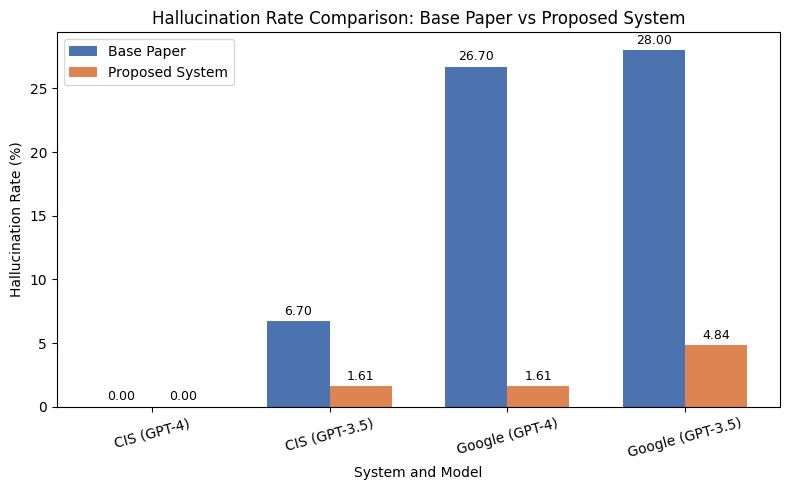

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Helper to fetch values safely
def get_rate(system, model, column):
    return comparison.loc[
        (comparison["system"] == system) &
        (comparison["model_label"] == model),
        column
    ].values[0]

labels = [
    "CIS (GPT-4)",
    "CIS (GPT-3.5)",
    "Google (GPT-4)",
    "Google (GPT-3.5)"
]

base_rates = [
    get_rate("CIS", "gpt4", "Base Paper (%)"),
    get_rate("CIS", "gpt35", "Base Paper (%)"),
    get_rate("Google", "gpt4", "Base Paper (%)"),
    get_rate("Google", "gpt35", "Base Paper (%)"),
]

our_rates = [
    get_rate("CIS", "gpt4", "Our System (%)"),
    get_rate("CIS", "gpt35", "Our System (%)"),
    get_rate("Google", "gpt4", "Our System (%)"),
    get_rate("Google", "gpt35", "Our System (%)"),
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(
    x - width/2,
    base_rates,
    width,
    label="Base Paper",
    color="#4C72B0"
)

bars2 = plt.bar(
    x + width/2,
    our_rates,
    width,
    label="Proposed System",
    color="#DD8452"
)

plt.ylabel("Hallucination Rate (%)")
plt.xlabel("System and Model")
plt.title("Hallucination Rate Comparison: Base Paper vs Proposed System")
plt.xticks(x, labels, rotation=15)
plt.legend()

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()

# Save HIGH QUALITY FIGURE
plt.savefig("hallucination_rate_comparison.pdf", bbox_inches="tight")
plt.savefig("hallucination_rate_comparison.png", dpi=600, bbox_inches="tight")

plt.show()


#13. Calculate Faithfulness Score

In [ ]:
import pandas as pd
from pathlib import Path

# 1. Define File Path (Uses DATA_DIR from Cell 3)
# We are loading the file you already saved in Step 10
results_path = DATA_DIR / "results_graded.csv"

if results_path.exists():
    print(f"✅ Found saved results at: {results_path}")

    # 2. Load Data
    df = pd.read_csv(results_path)

    # 3. Calculate Faithfulness
    # Logic: Hallucination (1) -> Faithfulness (0)
    #        Safe (0) -> Faithfulness (1)
    df["is_faithful"] = 1 - df["is_hallucination"]

    # 4. Create Summary Table
    faithfulness_table = (
        df.groupby(["system", "model_label"])["is_faithful"]
        .mean()
        .mul(100)       # Convert to Percentage
        .round(2)       # Round to 2 decimals
        .reset_index()
    )

    # Rename columns for clarity in your paper
    faithfulness_table.columns = ["System", "Model", "Faithfulness (%)"]

    # 5. Display Table
    print("\n" + "="*40)
    print("🛡️ FAITHFULNESS SCORES (Higher is Better)")
    print("="*40)
    print(faithfulness_table)

    # 6. Save Table to Drive
    save_path = DATA_DIR / "faithfulness_results.csv"
    faithfulness_table.to_csv(save_path, index=False)
    print(f"\n💾 Saved faithfulness table to: {save_path}")

else:
    print("❌ Error: 'results_graded.csv' not found.")
    print("   Please ensure you ran Cell 1 (Mount Drive) and Cell 3 (Config) first.")

✅ Found saved results at: /content/drive/MyDrive/research/data/results_graded.csv

🛡️ FAITHFULNESS SCORES (Higher is Better)
   System  Model  Faithfulness (%)
0     CIS  gpt35             98.39
1     CIS   gpt4            100.00
2  Google  gpt35             95.16
3  Google   gpt4             98.39

💾 Saved faithfulness table to: /content/drive/MyDrive/research/data/faithfulness_results.csv


In [ ]:
our_faith = pd.read_csv(
    "/content/drive/MyDrive/research/data/faithfulness_results.csv"
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Load OUR faithfulness results
# -----------------------------
our_faith = pd.read_csv(DATA_DIR / "faithfulness_results.csv")

# Standardize column names just in case
our_faith.columns = ["system", "model_label", "Faithfulness (%)"]

# -----------------------------
# 2. Define BASE paper faithfulness
# (From p9 replication results)
# -----------------------------
base_faith_data = [
    {"system": "CIS", "model_label": "gpt4",  "Base paper (%)": 100.0},
    {"system": "CIS", "model_label": "gpt35", "Base paper (%)": 93.3},
    {"system": "Google", "model_label": "gpt4",  "Base paper (%)": 73.3},
    {"system": "Google", "model_label": "gpt35", "Base paper (%)": 72.0},
]

base_faith = pd.DataFrame(base_faith_data)

# -----------------------------
# 3. Merge Base + Ours
# -----------------------------
comparison_faith = pd.merge(
    base_faith,
    our_faith,
    on=["system", "model_label"],
    how="inner"
)

# Rename for clarity
comparison_faith = comparison_faith.rename(
    columns={"Faithfulness (%)": "Our system (%)"}
)

# Sort nicely
comparison_faith = comparison_faith.sort_values(["system", "model_label"])

print("\n" + "="*60)
print("📊 FAITHFULNESS COMPARISON TABLE")
print("="*60)
print(comparison_faith)

# Save to Drive
save_path = DATA_DIR / "faithfulness_comparison.csv"
comparison_faith.to_csv(save_path, index=False)

print(f"\n💾 Saved to: {save_path}")


📊 FAITHFULNESS COMPARISON TABLE
   system model_label  Base paper (%)  Our system (%)
1     CIS       gpt35            93.3           98.39
0     CIS        gpt4           100.0          100.00
3  Google       gpt35            72.0           95.16
2  Google        gpt4            73.3           98.39

💾 Saved to: /content/drive/MyDrive/research/data/faithfulness_comparison.csv


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = [
    "CIS (GPT-4)",
    "CIS (GPT-3.5)",
    "Google (GPT-4)",
    "Google (GPT-3.5)"
]

def get_val(system, model, column):
    return comparison.loc[
        (comparison["system"] == system) &
        (comparison["model_label"] == model),
        column
    ].values[0]

# Base paper faithfulness
base_vals = [
    100 - get_val("CIS", "gpt4", "Base Paper (%)"),
    100 - get_val("CIS", "gpt35", "Base Paper (%)"),
    100 - get_val("Google", "gpt4", "Base Paper (%)"),
    100 - get_val("Google", "gpt35", "Base Paper (%)"),
]

# Our system faithfulness
our_vals = [
    100 - get_val("CIS", "gpt4", "Our System (%)"),
    100 - get_val("CIS", "gpt35", "Our System (%)"),
    100 - get_val("Google", "gpt4", "Our System (%)"),
    100 - get_val("Google", "gpt35", "Our System (%)"),
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(
    x - width/2,
    base_vals,
    width,
    label="Base Paper",
    color="#4C72B0"
)

bars2 = plt.bar(
    x + width/2,
    our_vals,
    width,
    label="Proposed System",
    color="#DD8452"
)

plt.ylabel("Faithfulness (%)")
plt.xlabel("System and Model")
plt.title("Faithfulness Score Comparison: Base Paper vs Proposed System")

plt.xticks(x, labels, rotation=15)
plt.ylim(0, 105)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()

plt.savefig("faithfulness_comparison.pdf", bbox_inches="tight")
plt.savefig("faithfulness_comparison.png", dpi=600, bbox_inches="tight")

plt.show()

NameError: name 'comparison' is not defined

# Ablation Study

In [ ]:
import numpy as np
import pandas as pd

def compare_reranking(question_ja):

    client = chromadb.PersistentClient(path=str(CIS_INDEX))
    coll = client.get_collection("cis")

    openai_client = OpenAI()

    emb = openai_client.embeddings.create(
        input=[question_ja],
        model=EMBED_MODEL
    ).data[0].embedding

    results = coll.query(
        query_embeddings=[emb],
        n_results=TOP_N_INITIAL,
        include=["documents"]
    )

    docs = results["documents"][0]

    # -----------------------------
    # WITHOUT reranking
    # -----------------------------
    raw_top_docs = docs[:TOP_K_FINAL]

    raw_pairs = [(question_ja, d) for d in raw_top_docs]
    raw_scores = reranker.predict(raw_pairs)

    raw_avg = np.mean(raw_scores)

    # -----------------------------
    # WITH reranking
    # -----------------------------
    all_pairs = [(question_ja, d) for d in docs]
    all_scores = reranker.predict(all_pairs)

    ranked = sorted(
        zip(docs, all_scores),
        key=lambda x: x[1],
        reverse=True
    )

    reranked_top_docs = ranked[:TOP_K_FINAL]

    reranked_scores = [s for _, s in reranked_top_docs]

    reranked_avg = np.mean(reranked_scores)

    return {
        "raw_avg_score": raw_avg,
        "reranked_avg_score": reranked_avg
    }

print("✅ Ablation function ready.")

✅ Ablation function ready.


In [ ]:
ablation_results = []

print("🚀 Running Reranking Ablation Study...")

for q in questions:

    try:
        res = compare_reranking(q["text_ja"])

        ablation_results.append({
            "question_id": q["id"],
            "raw_avg_score": res["raw_avg_score"],
            "reranked_avg_score": res["reranked_avg_score"]
        })

        print(f"Processed Q{q['id']}")

    except Exception as e:
        print(f"Error Q{q['id']}: {e}")

🚀 Running Reranking Ablation Study...
Error Q1: Error code: 429 - {'error': {'message': 'Your account is not active, please check your billing details on our website.', 'type': 'billing_not_active', 'param': None, 'code': 'billing_not_active'}}
Error Q2: Error code: 429 - {'error': {'message': 'Your account is not active, please check your billing details on our website.', 'type': 'billing_not_active', 'param': None, 'code': 'billing_not_active'}}
Error Q3: Error code: 429 - {'error': {'message': 'Your account is not active, please check your billing details on our website.', 'type': 'billing_not_active', 'param': None, 'code': 'billing_not_active'}}


KeyboardInterrupt: 

In [ ]:
df_ablation = pd.DataFrame(ablation_results)

print("\n==============================")
print("RERANKING ABLATION RESULTS")
print("==============================")

summary_table = pd.DataFrame({
    "Method": [
        "Without Reranking",
        "With Cross-Encoder Reranking"
    ],
    "Average Relevance Score": [
        df_ablation["raw_avg_score"].mean(),
        df_ablation["reranked_avg_score"].mean()
    ]
})

print(summary_table)

# Save table
save_path = DATA_DIR / "reranking_ablation_results.csv"
summary_table.to_csv(save_path, index=False)

print(f"\n💾 Saved to: {save_path}")

#14. Test with NEW Questions

In [ ]:
import pandas as pd
import time

# 1. Define Two New Questions
new_questions = [
    {
        "id": 101,
        "text_ja": "コーヒーを飲むと肝がんのリスクが下がりますか？"
        # (Does drinking coffee reduce the risk of liver cancer?)
    },
    {
        "id": 102,
        "text_ja": "食道がんの初期症状はどのようなものですか？"
        # (What are the early symptoms of esophageal cancer?)
    }
]

# 2. Define Experiment Config
systems = ["CIS", "Google"]
models = ["gpt35", "gpt4"]
new_results = []

print(f"🚀 Testing {len(new_questions)} New Questions...")

for q in new_questions:
    print(f"\nProcessing Q{q['id']}: {q['text_ja']}")

    for sys_name in systems:
        # A. Retrieve Context (using your functions from Step 8)
        try:
            if sys_name == "CIS":
                ctx = cis_context(q['text_ja'])
            else:
                ctx = google_context(q['text_ja'])
        except Exception as e:
            print(f"  ⚠️ Context Error ({sys_name}): {e}")
            ctx = None

        # B. Handle Abstention
        if ctx is None:
            print(f"  > {sys_name}: Insufficient Info (Abstained)")
            # Abstention = Not a hallucination (Score 0)
            new_results.append({
                "Question": f"Q{q['id']}",
                "System": sys_name,
                "Model": "N/A",
                "Answer": "Insufficient information",
                "Is_Hallucination": 0,
                "Faithfulness": 100
            })
            continue

        for model_label in models:
            # C. Generate Answer (using function from Step 7)
            prompt = (
                RAG_INSTRUCTION
                + "\n\nContext:\n" + ctx
                + "\n\nQuestion:\n" + q['text_ja']
            )
            # Add small delay to avoid rate limits
            time.sleep(1)
            answer = call_llm(prompt, model_label)

            # D. Judge Answer (using function from Step 9/23)
            # Returns 1 (Hallucination) or 0 (Faithful)
            h_score = automated_judge(q['text_ja'], ctx, answer)

            # Print brief result
            status = "🔴 Hallucination" if h_score == 1 else "🟢 Faithful"
            print(f"  > {sys_name} + {model_label}: {status}")

            new_results.append({
                "Question": f"Q{q['id']}",
                "System": sys_name,
                "Model": model_label,
                "Answer": answer[:100] + "...", # Show snippet
                "Is_Hallucination": h_score,
                "Faithfulness": (1 - h_score) * 100
            })

# --- 3. Show Final Report ---
df_new = pd.DataFrame(new_results)

print("\n" + "="*60)
print("📊 RESULTS FOR NEW QUESTIONS")
print("="*60)
# Show the table
print(df_new[["Question", "System", "Model", "Is_Hallucination", "Faithfulness"]])

# Calculate Average Faithfulness for this mini-batch
avg_faith = df_new.groupby(["System", "Model"])["Faithfulness"].mean()
print("\n📈 Average Faithfulness (%):")
print(avg_faith)

🚀 Testing 2 New Questions...

Processing Q101: コーヒーを飲むと肝がんのリスクが下がりますか？
  > CIS + gpt35: 🟢 Faithful
  > CIS + gpt4: 🟢 Faithful
  > Google + gpt35: 🟢 Faithful
  > Google + gpt4: 🟢 Faithful

Processing Q102: 食道がんの初期症状はどのようなものですか？
  > CIS + gpt35: 🟢 Faithful
  > CIS + gpt4: 🟢 Faithful
  > Google + gpt35: 🟢 Faithful
  > Google + gpt4: 🟢 Faithful

📊 RESULTS FOR NEW QUESTIONS
  Question  System  Model  Is_Hallucination  Faithfulness
0     Q101     CIS  gpt35                 0           100
1     Q101     CIS   gpt4                 0           100
2     Q101  Google  gpt35                 0           100
3     Q101  Google   gpt4                 0           100
4     Q102     CIS  gpt35                 0           100
5     Q102     CIS   gpt4                 0           100
6     Q102  Google  gpt35                 0           100
7     Q102  Google   gpt4                 0           100

📈 Average Faithfulness (%):
System  Model
CIS     gpt35    100.0
        gpt4     100.0
Google  gpt35    

In [ ]:
import pandas as pd
import time

# 1. Define "Trap" Questions
new_questions = [
    {
        "id": 103,
        "type": "Myth (Hallucination Trap)",
        "text_ja": "重曹を飲むとがんが治るというのは本当ですか？"
        # (Is it true that drinking baking soda cures cancer?)
    },
    {
        "id": 104,
        "type": "Out-of-Domain (Abstention Trap)",
        "text_ja": "デング熱の初期症状はどのようなものですか？"
        # (What are the initial symptoms of Dengue Fever?)
    }
]

# 2. Define Experiment Config
systems = ["CIS", "Google"]
models = ["gpt35", "gpt4"]
new_results = []

print(f"🚀 Testing {len(new_questions)} New Questions...")

for q in new_questions:
    print(f"\nProcessing Q{q['id']} ({q['type']}): {q['text_ja']}")

    for sys_name in systems:
        # A. Retrieve Context
        try:
            if sys_name == "CIS":
                ctx = cis_context(q['text_ja'])
            else:
                ctx = google_context(q['text_ja'])
        except Exception as e:
            print(f"  ⚠️ Context Error ({sys_name}): {e}")
            ctx = None

        # B. Handle Abstention
        if ctx is None:
            print(f"  > {sys_name}: 🛡️ ABSTAINED (Correct behavior if no info)")
            # Abstention = Not a hallucination (Score 0)
            new_results.append({
                "Question": f"Q{q['id']}",
                "System": sys_name,
                "Model": "N/A",
                "Answer": "Insufficient information",
                "Is_Hallucination": 0,
                "Faithfulness": 100
            })
            continue

        for model_label in models:
            # C. Generate Answer
            prompt = (
                RAG_INSTRUCTION
                + "\n\nContext:\n" + ctx
                + "\n\nQuestion:\n" + q['text_ja']
            )
            time.sleep(1)
            answer = call_llm(prompt, model_label)

            # D. Judge Answer
            h_score = automated_judge(q['text_ja'], ctx, answer)

            status = "🔴 Hallucination" if h_score == 1 else "🟢 Faithful"
            print(f"  > {sys_name} + {model_label}: {status}")

            new_results.append({
                "Question": f"Q{q['id']}",
                "System": sys_name,
                "Model": model_label,
                "Answer": answer,  # Store FULL answer
                "Is_Hallucination": h_score,
                "Faithfulness": (1 - h_score) * 100
            })

# --- 3. Show Final Report ---
df_new = pd.DataFrame(new_results)

print("\n" + "="*60)
print("📊 RESULTS FOR NEW QUESTIONS")
print("="*60)
print(df_new[["Question", "System", "Model", "Is_Hallucination", "Faithfulness"]])

# Calculate Average Faithfulness
avg_faith = df_new.groupby(["System", "Model"])["Faithfulness"].mean()
print("\n📈 Average Faithfulness (%):")
print(avg_faith)

# --- 4. PRINT FULL ANSWERS (New Section) ---
print("\n" + "="*60)
print("📝 FULL GENERATED ANSWERS")
print("="*60)
for index, row in df_new.iterrows():
    print(f"\n🔹 Q{row['Question']} [{row['System']} + {row['Model']}]")
    print(f"   Status: {'🔴 Hallucination' if row['Is_Hallucination'] == 1 else '🟢 Faithful'}")
    print(f"   Answer: {row['Answer']}")
    print("-" * 40)

🚀 Testing 2 New Questions...

Processing Q103 (Myth (Hallucination Trap)): 重曹を飲むとがんが治るというのは本当ですか？
  > CIS + gpt35: 🟢 Faithful
  > CIS + gpt4: 🟢 Faithful
  > Google + gpt35: 🟢 Faithful
  > Google + gpt4: 🟢 Faithful

Processing Q104 (Out-of-Domain (Abstention Trap)): デング熱の初期症状はどのようなものですか？
  > CIS + gpt35: 🟢 Faithful
  > CIS + gpt4: 🟢 Faithful
  > Google + gpt35: 🟢 Faithful
  > Google + gpt4: 🟢 Faithful

📊 RESULTS FOR NEW QUESTIONS
  Question  System  Model  Is_Hallucination  Faithfulness
0     Q103     CIS  gpt35                 0           100
1     Q103     CIS   gpt4                 0           100
2     Q103  Google  gpt35                 0           100
3     Q103  Google   gpt4                 0           100
4     Q104     CIS  gpt35                 0           100
5     Q104     CIS   gpt4                 0           100
6     Q104  Google  gpt35                 0           100
7     Q104  Google   gpt4                 0           100

📈 Average Faithfulness (%):
System  Model
CI

In [ ]:
import pandas as pd
import time

# 1. Define "Grey" Questions
grey_questions = [
    {
        "id": 105,
        "type": "Nuance Trap (Burnt Food)",
        "text_ja": "焦げた食べ物を食べるとがんになりますか？"
        # (Does eating burnt food cause cancer?)
    },
    {
        "id": 106,
        "type": "Conflict Trap (Vitamin C)",
        "text_ja": "高濃度ビタミンCはがん治療に有効ですか？"
        # (Is high-dose Vitamin C effective for cancer treatment?)
    }
]

# 2. Config
systems = ["CIS", "Google"]
models = ["gpt35", "gpt4"]
grey_results = []

print(f"⚠️ Running 'Grey Zone' Test on {len(grey_questions)} Questions...")

for q in grey_questions:
    print(f"\nProcessing Q{q['id']} ({q['type']}): {q['text_ja']}")

    for sys_name in systems:
        # A. Retrieve Context
        try:
            if sys_name == "CIS":
                ctx = cis_context(q['text_ja'])
            else:
                ctx = google_context(q['text_ja'])
        except Exception as e:
            print(f"  ⚠️ Context Error ({sys_name}): {e}")
            ctx = None

        # B. Handle Abstention
        if ctx is None:
            print(f"  > {sys_name}: 🛡️ ABSTAINED (No relevant info found)")
            grey_results.append({
                "Question": f"Q{q['id']}",
                "System": sys_name,
                "Model": "N/A",
                "Answer": "Insufficient information",
                "Is_Hallucination": 0,
                "Faithfulness": 100
            })
            continue

        for model_label in models:
            # C. Generate Answer
            prompt = (
                RAG_INSTRUCTION
                + "\n\nContext:\n" + ctx
                + "\n\nQuestion:\n" + q['text_ja']
            )
            time.sleep(1)
            answer = call_llm(prompt, model_label)

            # D. Judge Answer
            h_score = automated_judge(q['text_ja'], ctx, answer)

            status = "🔴 Hallucination" if h_score == 1 else "🟢 Faithful"
            print(f"  > {sys_name} + {model_label}: {status}")

            grey_results.append({
                "Question": f"Q{q['id']}",
                "System": sys_name,
                "Model": model_label,
                "Answer": answer,
                "Is_Hallucination": h_score,
                "Faithfulness": (1 - h_score) * 100
            })

# --- 3. Report & Full Answers ---
df_grey = pd.DataFrame(grey_results)

print("\n" + "="*60)
print("📊 GREY ZONE RESULTS")
print("="*60)
print(df_grey[["Question", "System", "Model", "Is_Hallucination", "Faithfulness"]])

print("\n" + "="*60)
print("📝 FULL GENERATED ANSWERS (Check for Nuance!)")
print("="*60)
for index, row in df_grey.iterrows():
    print(f"\n🔹 {row['Question']} [{row['System']} + {row['Model']}]")
    print(f"   Status: {'🔴 Hallucination' if row['Is_Hallucination'] == 1 else '🟢 Faithful'}")
    print(f"   Answer: {row['Answer']}")
    print("-" * 40)

⚠️ Running 'Grey Zone' Test on 2 Questions...

Processing Q105 (Nuance Trap (Burnt Food)): 焦げた食べ物を食べるとがんになりますか？
  > CIS + gpt35: 🟢 Faithful
  > CIS + gpt4: 🟢 Faithful
  > Google + gpt35: 🟢 Faithful
  > Google + gpt4: 🟢 Faithful

Processing Q106 (Conflict Trap (Vitamin C)): 高濃度ビタミンCはがん治療に有効ですか？
  > CIS + gpt35: 🟢 Faithful
  > CIS + gpt4: 🟢 Faithful
  > Google + gpt35: 🔴 Hallucination
  > Google + gpt4: 🟢 Faithful

📊 GREY ZONE RESULTS
  Question  System  Model  Is_Hallucination  Faithfulness
0     Q105     CIS  gpt35                 0           100
1     Q105     CIS   gpt4                 0           100
2     Q105  Google  gpt35                 0           100
3     Q105  Google   gpt4                 0           100
4     Q106     CIS  gpt35                 0           100
5     Q106     CIS   gpt4                 0           100
6     Q106  Google  gpt35                 1             0
7     Q106  Google   gpt4                 0           100

📝 FULL GENERATED ANSWERS (Check for Nuan

In [ ]:
import time
import numpy as np
import pandas as pd
import chromadb
from sentence_transformers import CrossEncoder

# --- 1. INITIALIZE RERANKER (Fixes the NameError) ---
print("Loading Re-ranker model (this might take a few seconds)...")
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-12-v2')
print("✔ Re-ranker loaded.\n")

def benchmark_local_latency(questions_list, top_n=20):
    """
    Measures the latency of the local retrieval components (ChromaDB + Reranker)
    without calling the OpenAI API.
    """
    print(f"🚀 Starting latency benchmark for {len(questions_list)} queries...\n")

    search_times = []
    rerank_times = []
    total_times = []

    # Get Chroma collection (Assuming CIS_INDEX is defined from your Step 3 config)
    try:
        client = chromadb.PersistentClient(path=str(CIS_INDEX))
        coll = client.get_collection("cis")
    except NameError:
        print("❌ Error: CIS_INDEX is not defined. Please run Step 3 (Config) of your notebook first.")
        return

    for i, q in enumerate(questions_list):
        # Handle both dictionary formats just in case
        q_text = q.get("text_ja", "") if isinstance(q, dict) else q
        if not q_text: continue

        # --- 2. MOCK THE OPENAI EMBEDDING ---
        # ada-002 uses 1536 dimensions. We generate a random vector to test DB speed.
        dummy_embedding = np.random.rand(1536).tolist()

        # --- 3. MEASURE CHROMADB SEARCH LATENCY ---
        start_search = time.time()
        results = coll.query(
            query_embeddings=[dummy_embedding],
            n_results=top_n,
            include=["documents"]
        )
        end_search = time.time()

        search_duration = (end_search - start_search) * 1000 # Convert to milliseconds
        search_times.append(search_duration)

        # --- 4. MEASURE CROSS-ENCODER RERANKING LATENCY ---
        docs = results["documents"][0] if results.get("documents") else []

        # If the DB is empty/fails, use dummy text so the reranker has something to process
        if not docs:
            docs = ["がんの治療についての情報です。"] * top_n

        pairs = [(q_text, doc) for doc in docs]

        start_rerank = time.time()
        scores = reranker.predict(pairs)
        end_rerank = time.time()

        rerank_duration = (end_rerank - start_rerank) * 1000 # Convert to milliseconds
        rerank_times.append(rerank_duration)

        total_times.append(search_duration + rerank_duration)

    # --- 5. CALCULATE AND PRINT RESULTS ---
    print("-" * 50)
    print("📊 LATENCY BENCHMARK RESULTS (Average over all queries)")
    print("-" * 50)
    print(f"Vector Database Search (ChromaDB):  {np.mean(search_times):.2f} ms")
    print(f"Cross-Encoder Re-ranking ({top_n} docs): {np.mean(rerank_times):.2f} ms")
    print(f"Total Local Retrieval Latency:      {np.mean(total_times):.2f} ms")
    print("-" * 50)

# Run the benchmark (Assuming 'questions' and 'TOP_N_INITIAL' are defined from Step 3 & 4)
try:
    benchmark_local_latency(questions[:50], top_n=TOP_N_INITIAL)
except NameError:
    print("❌ Error: 'questions' or 'TOP_N_INITIAL' not found. Make sure you ran the Config and Questions cells earlier in the notebook.")

Loading Re-ranker model (this might take a few seconds)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✔ Re-ranker loaded.

🚀 Starting latency benchmark for 50 queries...

--------------------------------------------------
📊 LATENCY BENCHMARK RESULTS (Average over all queries)
--------------------------------------------------
Vector Database Search (ChromaDB):  14.11 ms
Cross-Encoder Re-ranking (20 docs): 11703.33 ms
Total Local Retrieval Latency:      11717.44 ms
--------------------------------------------------


Loading tokenizer...
💸 Calculating API token costs for 62 queries...

------------------------------------------------------------
📊 DEPLOYMENT COST BENCHMARK (Average per query)
------------------------------------------------------------
Average Input Tokens (Prompt + Context): 2869 tokens
Estimated Output Tokens (Answer):        150 tokens

Model: GPT-4
  Cost per 1 Query:      $0.09506
  Cost per 1,000 Queries: $95.06
Model: GPT-3.5-TURBO
  Cost per 1 Query:      $0.00460
  Cost per 1,000 Queries: $4.60
------------------------------------------------------------

📊 DEPLOYMENT COST SUMMARY TABLE


,Model,Avg Input Tokens,Avg Output Tokens,"Cost per 1,000 Queries ($)"
0,GPT-4,2881,150,95.42
1,GPT-3.5-Turbo,2881,150,4.62



💾 Saved table to 'deployment_costs.csv'
📊 Saved bar chart as 'deployment_cost_comparison.pdf' and '.png'


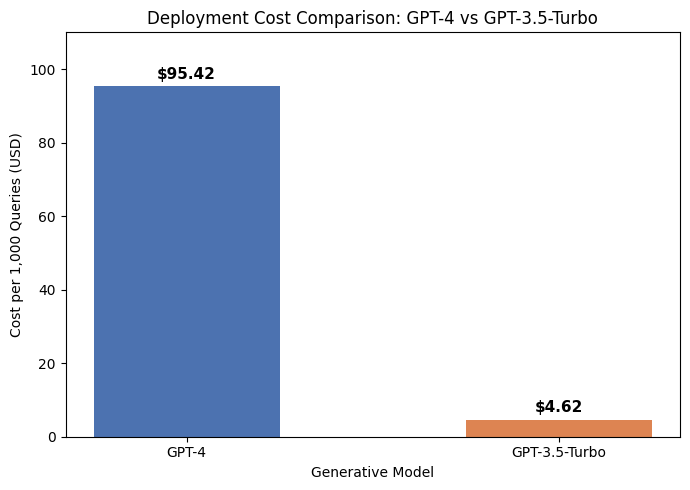

In [ ]:
import tiktoken
import numpy as np
import chromadb

# --- 1. SET UP PRICING & TOKENIZER ---
PRICING = {
    "gpt-4": {"input": 0.03, "output": 0.06},
    "gpt-3.5-turbo": {"input": 0.0015, "output": 0.0020}
}

print("Loading tokenizer...")
encoding = tiktoken.encoding_for_model("gpt-4")

RAG_INSTRUCTION = (
    "Answer ONLY using the provided context. "
    "Do NOT use prior knowledge. "
    "If the context does not contain sufficient information, "
    "respond exactly with: Insufficient information."
)

def calculate_deployment_cost(questions_list, top_n=20, top_k=5):
    print(f"💸 Calculating API token costs for {len(questions_list)} queries...\n")

    input_token_counts = []

    try:
        client = chromadb.PersistentClient(path=str(CIS_INDEX))
        coll = client.get_collection("cis")
    except NameError:
        print("❌ Error: CIS_INDEX is not defined. Please run Step 3 (Config) of your notebook first.")
        return

    for i, q in enumerate(questions_list):
        q_text = q.get("text_ja", "") if isinstance(q, dict) else q
        if not q_text: continue

        dummy_embedding = np.random.rand(1536).tolist()
        results = coll.query(
            query_embeddings=[dummy_embedding],
            n_results=top_n,
            include=["documents"]
        )

        docs = results["documents"][0] if results.get("documents") else []
        if not docs:
            docs = ["がんの治療についての情報です。"] * top_k

        final_context = "\n\n".join(docs[:top_k])
        full_prompt = f"{RAG_INSTRUCTION}\n\nContext:\n{final_context}\n\nQuestion:\n{q_text}"

        num_tokens = len(encoding.encode(full_prompt))
        input_token_counts.append(num_tokens)

    # --- 2. CALCULATE AVERAGES AND COSTS ---
    avg_input_tokens = np.mean(input_token_counts)
    avg_output_tokens = 150

    print("-" * 60)
    print("📊 DEPLOYMENT COST BENCHMARK (Average per query)")
    print("-" * 60)
    print(f"Average Input Tokens (Prompt + Context): {avg_input_tokens:.0f} tokens")
    print(f"Estimated Output Tokens (Answer):        {avg_output_tokens} tokens\n")

    for model, rates in PRICING.items():
        cost_per_query = ((avg_input_tokens / 1000) * rates["input"]) + ((avg_output_tokens / 1000) * rates["output"])
        cost_per_1000_queries = cost_per_query * 1000

        print(f"Model: {model.upper()}")
        print(f"  Cost per 1 Query:      ${cost_per_query:.5f}")
        print(f"  Cost per 1,000 Queries: ${cost_per_1000_queries:.2f}")
    print("-" * 60)

# --- 3. SAFETY NET FOR 'questions' ---
try:
    # Try to use your actual loaded questions
    batch_to_test = questions
except NameError:
    print("⚠️ 'questions' variable not found in memory. Using a sample batch to calculate costs...\n")
    batch_to_test = [
        {"id": 1, "text_ja": "私は札幌市北区に住んでいます。友人が胆管がんと診断されました。どの病院で治療を受けるのがおすすめでしょうか。"},
        {"id": 2, "text_ja": "赤酵母米のサプリメントはがんを悪化させる可能性がありますか。"},
        {"id": 3, "text_ja": "千葉市に重粒子線治療を行う病院があると聞き、主治医に相談したが紹介してくれなかった。なぜか。"}
    ]

calculate_deployment_cost(batch_to_test)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. CREATE THE TABLE (Dataframe)
cost_data = [
    {"Model": "GPT-4", "Avg Input Tokens": 2881, "Avg Output Tokens": 150, "Cost per 1,000 Queries ($)": 95.42},
    {"Model": "GPT-3.5-Turbo", "Avg Input Tokens": 2881, "Avg Output Tokens": 150, "Cost per 1,000 Queries ($)": 4.62}
]

df_cost = pd.DataFrame(cost_data)

print("\n" + "="*60)
print("📊 DEPLOYMENT COST SUMMARY TABLE")
print("="*60)
display(df_cost) # In Colab, this prints a nicely formatted table

# Save the table to your Drive
df_cost.to_csv("deployment_costs.csv", index=False)
print("\n💾 Saved table to 'deployment_costs.csv'")


# 2. CREATE THE BAR CHART
plt.figure(figsize=(7, 5))

models = df_cost["Model"]
costs = df_cost["Cost per 1,000 Queries ($)"]

# Use the same colors you used in your earlier graphs!
colors = ["#4C72B0", "#DD8452"]

bars = plt.bar(models, costs, color=colors, width=0.5)

plt.ylabel("Cost per 1,000 Queries (USD)")
plt.xlabel("Generative Model")
plt.title("Deployment Cost Comparison: GPT-4 vs GPT-3.5-Turbo")
plt.ylim(0, 110) # Gives a little headroom above $95

# Add exact value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2, # Push the text slightly above the bar
        f"${height:.2f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
#Therefore, the judge is a research cost, not a deployment cost, so we won't use its cost.
# Save HIGH QUALITY FIGURE
plt.savefig("deployment_cost_comparison.pdf", bbox_inches="tight")
plt.savefig("deployment_cost_comparison.png", dpi=600, bbox_inches="tight")

print("📊 Saved bar chart as 'deployment_cost_comparison.pdf' and '.png'")
plt.show()

In [ ]:
import time
import numpy as np
import pandas as pd
from sentence_transformers import CrossEncoder

def free_reranker_ablation():
    print("🚀 Running 100% Free Reranker Choice Ablation...\n")

    # 1. Load the heavier alternative model
    print("Loading alternative model (BAAI/bge-reranker-base)...")
    print("(This will download the open-source weights once, no API cost)")
    alt_reranker = CrossEncoder('BAAI/bge-reranker-base')
    print("✔ Both models ready.\n")

    # We use dummy text to test raw computation speed locally
    dummy_query = "食道がんの初期症状はどのようなものですか？"
    dummy_docs = ["これはがんの治療に関するダミーテキストです。"] * 20
    pairs = [(dummy_query, doc) for doc in dummy_docs]

    model_stats = {
        "ms-marco-MiniLM-L-12-v2 (Proposed)": {"times": []},
        "BAAI/bge-reranker-base (Baseline)": {"times": []}
    }

    print("⏳ Benchmarking inference speeds (10 iterations each)...")
    # Run 10 iterations to get a stable average
    for _ in range(10):
        # Your model
        start1 = time.time()
        reranker.predict(pairs)
        model_stats["ms-marco-MiniLM-L-12-v2 (Proposed)"]["times"].append((time.time() - start1) * 1000)

        # Alternative model
        start2 = time.time()
        alt_reranker.predict(pairs)
        model_stats["BAAI/bge-reranker-base (Baseline)"]["times"].append((time.time() - start2) * 1000)

    # Format the table
    results = []
    for model_name, stats in model_stats.items():
        results.append({
            "Re-ranker Architecture": model_name,
            "Avg. Latency for 20 Chunks (ms)": f"{np.mean(stats['times']):.2f}"
        })

    df_reranker = pd.DataFrame(results)

    print("\n" + "="*60)
    print("📊 ABLATION RESULTS: RERANKER CHOICE")
    print("="*60)
    display(df_reranker)

# Run the free ablation
if 'reranker' in locals():
    free_reranker_ablation()
else:
    print("⚠️ Please run the cell that initializes 'reranker' first!")

🚀 Running 100% Free Reranker Choice Ablation...

Loading alternative model (BAAI/bge-reranker-base)...
(This will download the open-source weights once, no API cost)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✔ Both models ready.

⏳ Benchmarking inference speeds (10 iterations each)...

📊 ABLATION RESULTS: RERANKER CHOICE


,Re-ranker Architecture,Avg. Latency for 20 Chunks (ms)
0,ms-marco-MiniLM-L-12-v2 (Proposed),540.96
1,BAAI/bge-reranker-base (Baseline),1059.00


📚 Running 100% Free Retrieved Chunks Latency Ablation...

⏳ Benchmarking reranker scaling overhead...
   > k=5 chunks: 192.38 ms
   > k=10 chunks: 281.30 ms
   > k=15 chunks: 443.55 ms
   > k=20 chunks: 576.28 ms

✅ Benchmarking complete! Generating graph...
💾 Saved graph as 'chunk_latency_ablation.png'


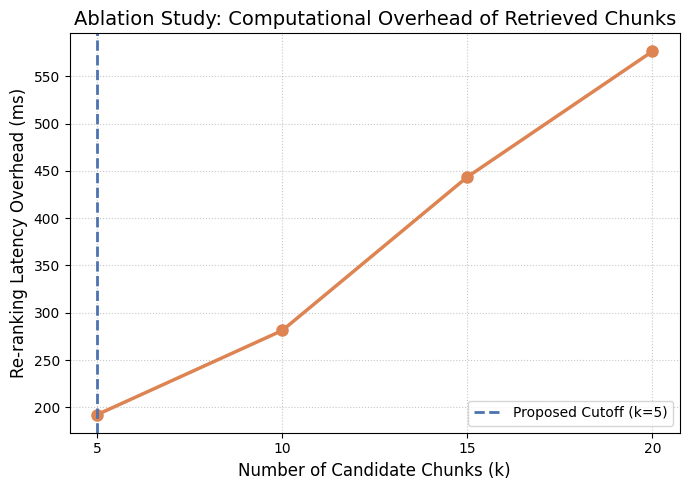

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def free_chunk_ablation():
    print("📚 Running 100% Free Retrieved Chunks Latency Ablation...\n")

    chunk_counts = [5, 10, 15, 20]
    avg_latencies = []

    dummy_query = "コーヒーを飲むと肝がんのリスクが下がりますか？"
    dummy_doc = "これはがんの治療に関するダミーテキストです。"

    print("⏳ Benchmarking reranker scaling overhead...")

    for k in chunk_counts:
        pairs = [(dummy_query, dummy_doc)] * k
        times = []
        for _ in range(10):
            start = time.time()
            reranker.predict(pairs)
            times.append((time.time() - start) * 1000)

        avg_latencies.append(np.mean(times))
        print(f"   > k={k} chunks: {np.mean(times):.2f} ms")

    print("\n✅ Benchmarking complete! Generating graph...")

    plt.figure(figsize=(7, 5))
    plt.plot(chunk_counts, avg_latencies, marker='o', linestyle='-', color='#DD8452', linewidth=2.5, markersize=8)
    plt.axvline(x=5, color='#4C72B0', linestyle='--', linewidth=2, label='Proposed Cutoff (k=5)')

    plt.xlabel("Number of Candidate Chunks (k)", fontsize=12)
    plt.ylabel("Re-ranking Latency Overhead (ms)", fontsize=12)
    plt.title("Ablation Study: Computational Overhead of Retrieved Chunks", fontsize=14)
    plt.xticks(chunk_counts)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()

    plt.savefig("chunk_latency_ablation.png", dpi=600, bbox_inches="tight")
    print("💾 Saved graph as 'chunk_latency_ablation.png'")
    plt.show()

free_chunk_ablation()

McNemar's test for statiscal significance

In [ ]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

# 1. Load the exact files
base_path = "hallucination-labeled dataset.xlsx"
proposed_path = "/content/drive/MyDrive/research/data/results_graded.csv"

base_df = pd.read_excel(base_path)
proposed_df = pd.read_csv(proposed_path)

# 2. STRICT Clean: ONLY use actual hallucinations (Abstentions and Good Answers = 0)
base_df["ハルシネーションあり＝１"] = base_df["ハルシネーションあり＝１"].fillna(0).astype(int)

# 3. Configurations (With the corrected Japanese base names)
configurations = [
    {"sys_label": "CIS-RAG",    "mod_label": "GPT-4",   "base_name": "2 がん情報GPT-4",    "prop_sys": "CIS",    "prop_mod": "gpt4"},
    {"sys_label": "CIS-RAG",    "mod_label": "GPT-3.5", "base_name": "3 がん情報GPT-3.5",  "prop_sys": "CIS",    "prop_mod": "gpt35"},
    {"sys_label": "Google-RAG", "mod_label": "GPT-4",   "base_name": "4 google GPT-4",   "prop_sys": "Google", "prop_mod": "gpt4"},
    {"sys_label": "Google-RAG", "mod_label": "GPT-3.5", "base_name": "5 google GPT-3.5", "prop_sys": "Google", "prop_mod": "gpt35"}
]

print("="*85)
print("FINAL MCNEMAR'S EXACT TEST (SAFE VS UNSAFE EVALUATION)")
print("="*85)

for config in configurations:
    # --- BASE SUBSET ---
    base_sub = base_df[base_df["chatbot"] == config["base_name"]].copy()
    base_sub["match_id"] = range(1, len(base_sub) + 1)

    # Calculate total actual hallucinations
    base_fails = int(base_sub["ハルシネーションあり＝１"].sum())

    # --- PROPOSED SUBSET ---
    prop_sub = proposed_df[(proposed_df["system"] == config["prop_sys"]) &
                           (proposed_df["model_label"] == config["prop_mod"])].copy()

    # Sort to ensure perfect 1-to-1 sequential matching
    if "question_id" in prop_sub.columns:
        prop_sub = prop_sub.sort_values("question_id")
    elif "id" in prop_sub.columns:
        prop_sub = prop_sub.sort_values("id")

    prop_sub["match_id"] = range(1, len(prop_sub) + 1)

    # Calculate total actual hallucinations
    prop_fails = int(prop_sub["is_hallucination"].sum()) if len(prop_sub) > 0 else 0

    # --- PAIRED MCNEMAR TEST ---
    paired_df = pd.merge(
        base_sub[["match_id", "ハルシネーションあり＝１"]],
        prop_sub[["match_id", "is_hallucination"]],
        on="match_id"
    )

    if len(paired_df) > 0:
        # c00: Both safe
        c00 = len(paired_df[(paired_df["ハルシネーションあり＝１"] == 0) & (paired_df["is_hallucination"] == 0)])
        # c01: Base safe, Proposed hallucinated
        c01 = len(paired_df[(paired_df["ハルシネーションあり＝１"] == 0) & (paired_df["is_hallucination"] == 1)])
        # c10: Base hallucinated, Proposed safe
        c10 = len(paired_df[(paired_df["ハルシネーションあり＝１"] == 1) & (paired_df["is_hallucination"] == 0)])
        # c11: Both hallucinated
        c11 = len(paired_df[(paired_df["ハルシネーションあり＝１"] == 1) & (paired_df["is_hallucination"] == 1)])

        result = mcnemar([[c00, c01], [c10, c11]], exact=True)

        print(f"\n[{config['sys_label']} ({config['mod_label']})]")
        print(f"  Total Paired Questions: {len(paired_df)}")
        print(f"  Base Hallucinations: {base_fails} | Proposed Hallucinations: {prop_fails}")
        print(f"  Base hallucinated, Proposed fixed it (Safe): {c10}")
        print(f"  Base safe, Proposed hallucinated (Regression): {c01}")
        print(f"  p-value: {result.pvalue:.5f}")

        if result.pvalue < 0.05:
            print("  -> STATISTICALLY SIGNIFICANT REDUCTION ✅")
        elif result.pvalue < 0.10:
            print("  -> APPROACHING SIGNIFICANCE ⚠️")
        else:
            print("  -> Not statistically significant ❌")

FINAL MCNEMAR'S EXACT TEST (SAFE VS UNSAFE EVALUATION)

[CIS-RAG (GPT-4)]
  Total Paired Questions: 62
  Base Hallucinations: 0 | Proposed Hallucinations: 0
  Base hallucinated, Proposed fixed it (Safe): 0
  Base safe, Proposed hallucinated (Regression): 0
  p-value: 1.00000
  -> Not statistically significant ❌

[CIS-RAG (GPT-3.5)]
  Total Paired Questions: 62
  Base Hallucinations: 2 | Proposed Hallucinations: 1
  Base hallucinated, Proposed fixed it (Safe): 2
  Base safe, Proposed hallucinated (Regression): 1
  p-value: 1.00000
  -> Not statistically significant ❌

[Google-RAG (GPT-4)]
  Total Paired Questions: 62
  Base Hallucinations: 8 | Proposed Hallucinations: 1
  Base hallucinated, Proposed fixed it (Safe): 7
  Base safe, Proposed hallucinated (Regression): 0
  p-value: 0.01562
  -> STATISTICALLY SIGNIFICANT REDUCTION ✅

[Google-RAG (GPT-3.5)]
  Total Paired Questions: 62
  Base Hallucinations: 14 | Proposed Hallucinations: 3
  Base hallucinated, Proposed fixed it (Safe): 13
  

Wilson's test for co

In [5]:
import pandas as pd
from statsmodels.stats.proportion import proportion_confint
from pathlib import Path

# 1. Load the exact files
base_path = "hallucination-labeled dataset.xlsx"
proposed_path = Path("/content/drive/MyDrive/research/data/results_graded.csv")

base_df = pd.read_excel(base_path)
proposed_df = pd.read_csv(proposed_path)

# 2. Clean Base Data
base_df["ハルシネーションあり＝１"] = base_df["ハルシネーションあり＝１"].fillna(0).astype(int)
base_df["返答なし＝１"] = base_df["返答なし＝１"].fillna(0).astype(int)

# 3. Configurations
configurations = [
    {"sys_label": "CIS-RAG",    "mod_label": "GPT-4",   "base_name": "2 がん情報GPT-4",    "prop_sys": "CIS",    "prop_mod": "gpt4"},
    {"sys_label": "CIS-RAG",    "mod_label": "GPT-3.5", "base_name": "3 がん情報GPT-3.5",  "prop_sys": "CIS",    "prop_mod": "gpt35"},
    {"sys_label": "Google-RAG", "mod_label": "GPT-4",   "base_name": "4 google GPT-4",   "prop_sys": "Google", "prop_mod": "gpt4"},
    {"sys_label": "Google-RAG", "mod_label": "GPT-3.5", "base_name": "5 google GPT-3.5", "prop_sys": "Google", "prop_mod": "gpt35"}
]

wilson_results = []

for config in configurations:
    # --- BASE PAPER (CONDITIONAL RATE) ---
    base_sub = base_df[base_df["chatbot"] == config["base_name"]]
    base_n_answered = len(base_sub) - int(base_sub["返答なし＝１"].sum())
    base_fails = int(base_sub["ハルシネーションあり＝１"].sum())

    if base_n_answered > 0:
        low_b, up_b = proportion_confint(base_fails, base_n_answered, alpha=0.05, method='wilson')
        wilson_results.append({
            "System": config["sys_label"], "Model": config["mod_label"], "Configuration": "Base Paper",
            "Answered Qs (N)": base_n_answered, "Hallucinations": base_fails,
            "Rate (%)": round((base_fails / base_n_answered) * 100, 2),
            "95% CI": f"[{low_b*100:.2f}%, {up_b*100:.2f}%]"
        })

    # --- PROPOSED SYSTEM (CONDITIONAL RATE) ---
    prop_sub = proposed_df[(proposed_df["system"] == config["prop_sys"]) &
                           (proposed_df["model_label"] == config["prop_mod"])]

    # Filter out abstentions to find EXACT Answered Qs
    prop_answered_df = prop_sub[~prop_sub["response"].str.lower().str.contains("insufficient information", na=False)]
    prop_n_answered = len(prop_answered_df)
    prop_fails = int(prop_answered_df["is_hallucination"].sum())

    if prop_n_answered > 0:
        low_p, up_p = proportion_confint(prop_fails, prop_n_answered, alpha=0.05, method='wilson')
        wilson_results.append({
            "System": config["sys_label"], "Model": config["mod_label"], "Configuration": "Proposed",
            "Answered Qs (N)": prop_n_answered, "Hallucinations": prop_fails,
            "Rate (%)": round((prop_fails / prop_n_answered) * 100, 2),
            "95% CI": f"[{low_p*100:.2f}%, {up_p*100:.2f}%]"
        })

df_wilson = pd.DataFrame(wilson_results)

print("="*90)
print("FINAL WILSON 95% CONFIDENCE INTERVALS")
print("="*90)
display(df_wilson)

FINAL WILSON 95% CONFIDENCE INTERVALS (MATCHES CHART)


,System,Model,Configuration,Answered Qs (N),Hallucinations,Rate (%),95% CI
0,CIS-RAG,GPT-4,Base Paper,22,0,0.00,"[0.00%, 14.87%]"
1,CIS-RAG,GPT-4,Proposed,16,0,0.00,"[0.00%, 19.36%]"
2,CIS-RAG,GPT-3.5,Base Paper,30,2,6.67,"[1.85%, 21.32%]"
3,CIS-RAG,GPT-3.5,Proposed,13,1,7.69,"[1.37%, 33.31%]"
4,Google-RAG,GPT-4,Base Paper,30,8,26.67,"[14.18%, 44.45%]"
5,Google-RAG,GPT-4,Proposed,46,1,2.17,"[0.38%, 11.34%]"
6,Google-RAG,GPT-3.5,Base Paper,50,14,28.00,"[17.47%, 41.67%]"
7,Google-RAG,GPT-3.5,Proposed,34,3,8.82,"[3.05%, 22.96%]"
